# TPCRP Modification: Intra-Cluster Typicality (TPCRP-IC)

## The Flaw in Original TPCRP

Typicality in the original algorithm is computed **globally** across all 50,000
unlabeled points, then used for **per-cluster** selection. A point near the boundary
of cluster A may score high global typicality simply because it has many neighbours
from adjacent cluster B, making it appear dense, while actually being the least
pure representative of its own cluster.

## The Modification

**TPCRP-IC** computes typicality **within each cluster only**, using adaptive
`K = min(20, cluster_size // 2)`. This ensures the selected point is the most
representative of its cluster, not just the globally densest point that happens to belong to it.

Original TPCRP and Random baseline results are loaded directly from the eval
notebook. Only TPCRP-IC is re-run here. Due to compute constraints, evaluation
covers **Framework 1** (fully supervised) and **Framework 2** (linear probe) only.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Embeddings from notebook 1
embeddings = np.load('embeddings.npy')
labels     = np.load('labels.npy')

# Original results from eval notebook
all_orig = np.load('tpcrp_accuracies.npy')      
all_rand = np.load('random_accuracies.npy')     
lp_orig  = np.load('tpcrp_lp_accuracies.npy')   
lp_rand  = np.load('random_lp_accuracies.npy')  

print(f"Embeddings: {embeddings.shape}")
print(f"Loaded original TPCRP F1: {all_orig.shape} | Random F1: {all_rand.shape}")
print(f"Loaded original TPCRP F2: {lp_orig.shape}  | Random F2: {lp_rand.shape}")

# CIFAR-10 loaders
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
])
pool_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=False, transform=eval_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                 download=False, transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=512,
                          shuffle=False, num_workers=4)
print("Ready!")

Using device: cuda
Embeddings: (50000, 512)
Loaded original TPCRP F1: (10, 5) | Random F1: (10, 5)
Loaded original TPCRP F2: (10, 5)  | Random F2: (10, 5)
Ready!


## Modified TPCRP-IC: Intra-Cluster Typicality

Instead of looking up pre-computed global scores, TPCRP-IC computes KNN
**within each cluster independently**. K is also adaptive: `min(20, cluster_size // 2)`,
preventing K from exceeding cluster size on small clusters, a silent failure
mode in the original when clusters have fewer than 20 points.

In [3]:
def tpcrp_ic_select(embeddings, budget, labeled_indices=None,
                    max_clusters=500, random_state=42):
    """
    TPCRP-IC: Intra-Cluster Typicality.
    Modification: typicality computed locally within each cluster
    using adaptive K = min(20, cluster_size // 2).
    """
    n_clusters = min(
        len(labeled_indices) + budget if labeled_indices is not None else budget,
        max_clusters
    )
    kmeans = (KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
              if n_clusters <= 50 else
              MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, n_init=10))
    cluster_assignments = kmeans.fit_predict(embeddings)

    if labeled_indices is not None and len(labeled_indices) > 0:
        labeled_clusters = set(cluster_assignments[labeled_indices])
        uncovered = [c for c in range(n_clusters) if c not in labeled_clusters]
    else:
        uncovered = list(range(n_clusters))

    cluster_sizes    = {c: np.sum(cluster_assignments == c) for c in uncovered}
    largest_clusters = sorted(uncovered, key=lambda c: cluster_sizes[c], reverse=True)[:budget]

    selected = []
    for cid in largest_clusters:
        mask         = np.where(cluster_assignments == cid)[0]
        cluster_embs = embeddings[mask]
        cluster_size = len(mask)

        k = min(20, cluster_size // 2)
        if k < 1 or cluster_size <= 2:
            selected.append(mask[0])
            continue

        nbrs         = NearestNeighbors(n_neighbors=k+1).fit(cluster_embs)
        distances, _ = nbrs.kneighbors(cluster_embs)
        avg_dist     = distances[:, 1:].mean(axis=1)
        local_typ    = 1.0 / (avg_dist + 1e-8)
        selected.append(mask[np.argmax(local_typ)])

    return np.array(selected)

print("TPCRP-IC defined.")

TPCRP-IC defined.


## Framework 1: Fully Supervised TPCRP-IC Evaluation

TPCRP-IC is run for 10 repetitions × 5 rounds. Original TPCRP and Random
results are loaded from the eval notebook, no recomputation needed.

In [5]:
def train_classifier(train_indices, pool_dataset, test_loader, device, epochs=100):
    labeled_loader = DataLoader(Subset(pool_dataset, train_indices),
                                batch_size=32, shuffle=True, num_workers=0)
    classifier     = models.resnet18(weights=None)
    classifier.fc  = nn.Linear(512, 10)
    classifier     = classifier.to(device)
    optimizer      = optim.SGD(classifier.parameters(), lr=0.025,
                               momentum=0.9, nesterov=True)
    scheduler      = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion      = nn.CrossEntropyLoss()

    classifier.train()
    for epoch in range(epochs):
        for imgs, targets in labeled_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(classifier(imgs), targets)
            loss.backward()
            optimizer.step()
        scheduler.step()

    classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            _, pred = classifier(imgs).max(1)
            correct += pred.eq(targets).sum().item()
            total   += targets.size(0)
    return 100. * correct / total

N_REPS = 10
BUDGET = 10
all_ic = []

for rep in range(N_REPS):
    print(f"\nRep {rep+1}/{N_REPS}")
    ic_idx, ic_accs = [], []

    for r in range(5):
        new = tpcrp_ic_select(embeddings, BUDGET,
                              labeled_indices=np.array(ic_idx) if ic_idx else None)
        ic_idx.extend(new.tolist())
        acc = train_classifier(ic_idx, pool_dataset, test_loader, device)
        ic_accs.append(acc)
        print(f"Round {r+1} | TPCRP-IC: {acc:.2f}%")

    all_ic.append(ic_accs)

all_ic = np.array(all_ic)
np.save('mod_ic_accs.npy', all_ic)
print(f"\nTPCRP-IC mean: {all_ic.mean(axis=0).round(2)}")
print(f"Original mean: {all_orig.mean(axis=0).round(2)}")
print(f"Random mean:   {all_rand.mean(axis=0).round(2)}")


Rep 1/10
Round 1 | TPCRP-IC: 15.83%
Round 2 | TPCRP-IC: 17.03%
Round 3 | TPCRP-IC: 20.55%
Round 4 | TPCRP-IC: 23.89%
Round 5 | TPCRP-IC: 22.36%

Rep 2/10
Round 1 | TPCRP-IC: 15.35%
Round 2 | TPCRP-IC: 17.80%
Round 3 | TPCRP-IC: 20.54%
Round 4 | TPCRP-IC: 21.61%
Round 5 | TPCRP-IC: 23.90%

Rep 3/10
Round 1 | TPCRP-IC: 14.64%
Round 2 | TPCRP-IC: 16.63%
Round 3 | TPCRP-IC: 20.34%
Round 4 | TPCRP-IC: 22.34%
Round 5 | TPCRP-IC: 24.70%

Rep 4/10
Round 1 | TPCRP-IC: 16.34%
Round 2 | TPCRP-IC: 18.56%
Round 3 | TPCRP-IC: 20.85%
Round 4 | TPCRP-IC: 22.54%
Round 5 | TPCRP-IC: 27.23%

Rep 5/10
Round 1 | TPCRP-IC: 13.67%
Round 2 | TPCRP-IC: 16.54%
Round 3 | TPCRP-IC: 22.60%
Round 4 | TPCRP-IC: 22.78%
Round 5 | TPCRP-IC: 22.44%

Rep 6/10
Round 1 | TPCRP-IC: 16.59%
Round 2 | TPCRP-IC: 18.55%
Round 3 | TPCRP-IC: 19.48%
Round 4 | TPCRP-IC: 24.14%
Round 5 | TPCRP-IC: 22.40%

Rep 7/10
Round 1 | TPCRP-IC: 14.53%
Round 2 | TPCRP-IC: 16.70%
Round 3 | TPCRP-IC: 21.01%
Round 4 | TPCRP-IC: 22.90%
Round 5 | TP

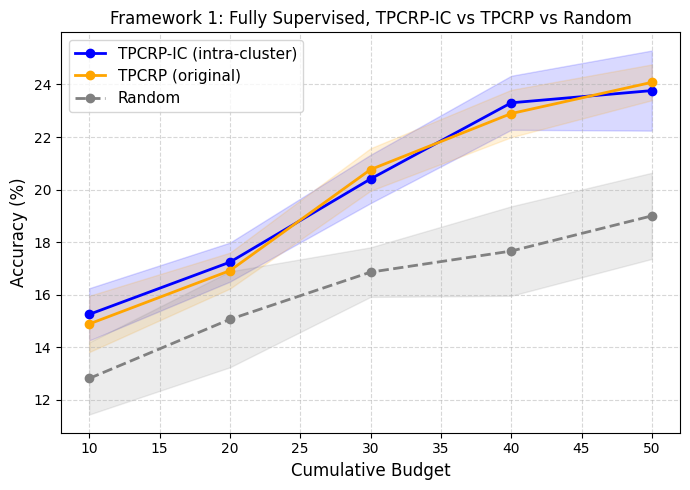

In [13]:
all_ic = np.load('mod_ic_accs.npy')
budgets = [10, 20, 30, 40, 50]

fig, ax = plt.subplots(figsize=(7, 5))
for data, label, color, ls in [
    (all_ic,   'TPCRP-IC (intra-cluster)',  'blue',   '-'),
    (all_orig, 'TPCRP (original)', 'orange', '-'),
    (all_rand, 'Random',           'gray',   '--'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(budgets, mean, marker='o', color=color,
            linestyle=ls, linewidth=2, label=label)
    ax.fill_between(budgets, mean - std, mean + std,
                    alpha=0.15, color=color)

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework 1: Fully Supervised, TPCRP-IC vs TPCRP vs Random', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_mod_framework1.png', dpi=150)
plt.show()

## Framework 2: Self-Supervised Embedding TPCRP-IC Evaluation

In [6]:
if os.path.exists('test_embeddings.npy'):
    test_embeddings = np.load('test_embeddings.npy')
    test_labels_arr = np.load('test_labels.npy')
    print(f"Test embeddings loaded: {test_embeddings.shape}")
else:
    class SimCLR(nn.Module):
        def __init__(self, projection_dim=128):
            super().__init__()
            resnet = models.resnet18(weights=None)
            self.encoder   = nn.Sequential(*list(resnet.children())[:-1])
            self.projector = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, projection_dim))
        def forward(self, x):
            h = self.encoder(x).squeeze()
            return h, self.projector(h)

    simclr = SimCLR().to(device)
    simclr.load_state_dict(torch.load('simclr_model.pth', map_location=device))
    simclr.eval()
    t_embs, t_lbls = [], []
    with torch.no_grad():
        for imgs, targets in tqdm(test_loader, desc="Extracting"):
            h, _ = simclr(imgs.to(device))
            h = nn.functional.normalize(h, dim=1)
            t_embs.append(h.cpu().numpy())
            t_lbls.append(targets.numpy())
    test_embeddings = np.concatenate(t_embs)
    test_labels_arr = np.concatenate(t_lbls)
    np.save('test_embeddings.npy', test_embeddings)
    np.save('test_labels.npy',     test_labels_arr)
    print(f"Test embeddings: {test_embeddings.shape}")

def train_linear_probe(labeled_indices, train_embs, train_lbls,
                       test_embs, test_lbls):
    clf = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
    clf.fit(train_embs[labeled_indices], train_lbls[labeled_indices])
    return 100. * (clf.predict(test_embs) == test_lbls).mean()

lp_ic = []

for rep in range(N_REPS):
    print(f"\nLinear Probe Rep {rep+1}/{N_REPS}")
    ic_idx, ic_accs = [], []

    for r in range(5):
        new = tpcrp_ic_select(embeddings, BUDGET,
                              labeled_indices=np.array(ic_idx) if ic_idx else None)
        ic_idx.extend(new.tolist())
        acc = train_linear_probe(ic_idx, embeddings, labels,
                                 test_embeddings, test_labels_arr)
        ic_accs.append(acc)

    lp_ic.append(ic_accs)
    print(f"TPCRP-IC: {[f'{x:.2f}' for x in ic_accs]}")

lp_ic = np.array(lp_ic)
np.save('mod_lp_ic.npy', lp_ic)
print(f"\nTPCRP-IC mean: {lp_ic.mean(axis=0).round(2)}")
print(f"Original mean: {lp_orig.mean(axis=0).round(2)}")
print(f"Random mean:   {lp_rand.mean(axis=0).round(2)}")

Extracting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 98.62it/s]


Test embeddings: (10000, 512)

Linear Probe Rep 1/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 2/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 3/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 4/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 5/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 6/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 7/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 8/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 9/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

Linear Probe Rep 10/10
TPCRP-IC: ['15.06', '49.35', '54.62', '62.67', '60.85']

TPCRP-IC mean: [15.06 49.35 54.62 62.67 60.85]
Original mean: [13.11 36.95 52.12 62.8  64.54]
Random mean:   [18.51 28.39 36.96 42.86 47.72]


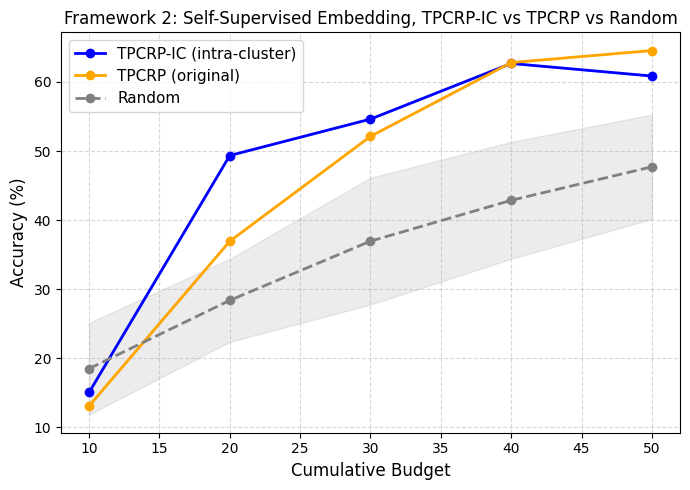

In [12]:
lp_ic = np.load('mod_lp_ic.npy')

fig, ax = plt.subplots(figsize=(7, 5))
for data, label, color, ls in [
    (lp_ic,   'TPCRP-IC (intra-cluster)',  'blue',   '-'),
    (lp_orig, 'TPCRP (original)', 'orange', '-'),
    (lp_rand, 'Random',           'gray',   '--'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(budgets, mean, marker='o', color=color,
            linestyle=ls, linewidth=2, label=label)
    ax.fill_between(budgets, mean - std, mean + std,
                    alpha=0.15, color=color)

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework 2: Self-Supervised Embedding, TPCRP-IC vs TPCRP vs Random', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_mod_framework2.png', dpi=150)
plt.show()

## Code Repository

Full implementation available at:
https://github.com/Hussain-AB/typiclust_cw.git